In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("superstore_3_csv.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,consumer,United States,HENDERSON,...,42420,South,FUR-BO-10001798,furniture,bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,CONSUMER,United States,Henderson,...,42420,South,FUR-CH-10000454,FURNITURE,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,LOS ANGELES,...,90036,West,OFF-LA-10000240,Office Supplies,labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,OFFICE SUPPLIES,storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


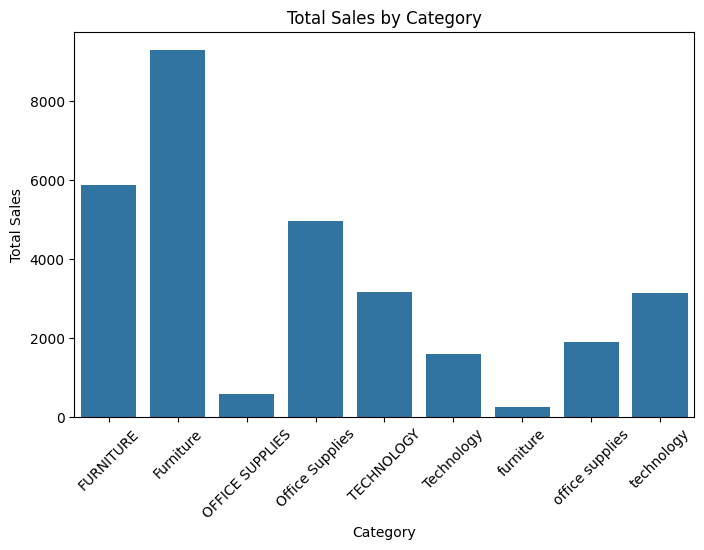

In [3]:
category_sales = df.groupby("Category")["Sales"].sum()
plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

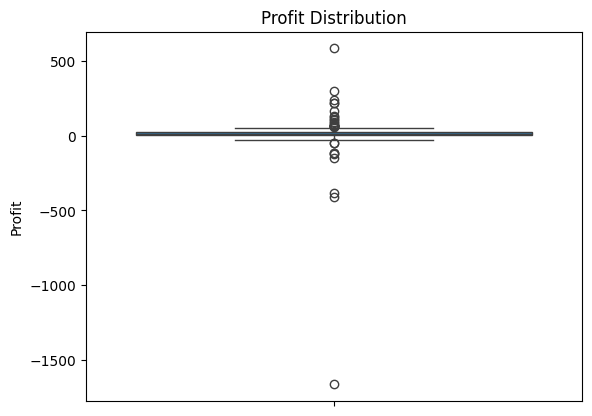

In [6]:
sns.boxplot(y=df["Profit"])
plt.title("Profit Distribution")
plt.ylabel("Profit")
plt.show()

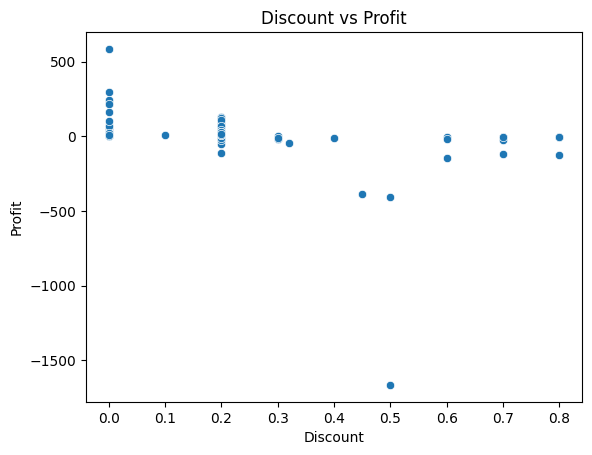

In [7]:
sns.scatterplot(data=df, x="Discount", y="Profit")
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

In [8]:
numerical_data = df.select_dtypes(include="number")
correlation_matrix = numerical_data.corr()
correlation_matrix

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
Row ID,1.000000,0.034805,-0.120677,0.091825,-0.091804,0.112491
Postal Code,0.034805,1.000000,0.010394,-0.005844,0.039913,0.109560
Sales,-0.120677,0.010394,1.000000,0.307215,0.053646,-0.323908
Quantity,0.091825,-0.005844,0.307215,1.000000,-0.020580,-0.026155
Discount,-0.091804,0.039913,0.053646,-0.020580,1.000000,-0.301511
Profit,0.112491,0.109560,-0.323908,-0.026155,-0.301511,1.000000


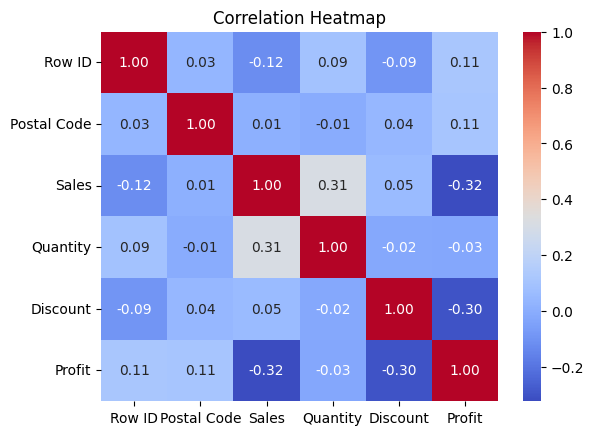

In [9]:
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

In [10]:
category_profit = df.groupby("Category")["Profit"].sum()
print(category_profit)
highest_profit_category = category_profit.idxmax()
print("Category with Highest Total Profit:", highest_profit_category)
print("Highest Total Profit:", category_profit.max())

Category
FURNITURE            33.8991
Furniture         -1358.3410
OFFICE SUPPLIES     160.2718
Office Supplies     880.5199
TECHNOLOGY          396.2234
Technology          271.0322
furniture            41.9136
office supplies     330.6316
technology          288.4725
Name: Profit, dtype: float64
Category with Highest Total Profit: Office Supplies
Highest Total Profit: 880.5199
